<a href="https://colab.research.google.com/github/adarsh-agent/GTU_Internship/blob/main/Day_6(11_07_26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
energy_df = pd.read_csv("/content/owid-energy-data.csv")
energy_df

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23372,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,NaN,0.0,0.0,0.0,6.440441,...,0.298063,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23373,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,NaN,0.0,0.0,0.0,6.963251,...,0.233372,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23374,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,NaN,0.0,0.0,0.0,6.845453,...,0.335570,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
23375,Zimbabwe,2023,ZWE,16340829.0,NaN,NaN,0.0,0.0,0.0,7.343568,...,0.300300,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN


In [6]:
energy_df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [7]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), object(2)
memory usage: 23.2+ MB


In [8]:
energy_df.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,23377.000000,1.889400e+04,1.178000e+04,2070.000000,7903.000000,6338.000000,8057.000000,6015.000000,6337.000000,6311.000000,...,7869.000000,6379.000000,2798.000000,6293.000000,6405.000000,8405.000000,9507.000000,5145.000000,7661.000000,6379.000000
mean,1976.238611,1.058587e+08,4.257565e+11,43.478821,1.054261,55.157110,15.092053,70.470840,12.503951,1.961657,...,1.115397,0.219811,290.408295,6.021235,48.691258,70.093753,21.368874,214.958756,1.712025,0.518142
std,35.331092,4.720948e+08,3.507870e+12,286.672304,6.641947,180.660546,75.942537,200.084733,53.260917,5.353897,...,3.337844,0.766123,6070.498588,34.260035,281.755752,277.601211,127.539439,733.879405,4.962740,1.722173
min,1900.000000,1.776000e+03,1.642060e+08,-100.000000,-59.083984,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-46.534790,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1949.000000,1.599088e+06,1.426394e+10,-0.968287,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,2.328556,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1985.000000,6.951653e+06,4.357680e+10,6.695433,0.000000,0.000000,0.000000,0.875653,0.020000,0.153061,...,0.000000,0.000000,18.349456,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2005.000000,2.581793e+07,1.830576e+11,23.320313,0.000000,0.506788,0.061667,44.131332,0.880000,1.600195,...,0.294424,0.005892,45.211092,0.095950,0.915601,2.195791,0.133600,25.914005,0.629577,0.074523
max,2025.000000,8.231613e+09,1.301126e+14,6373.061523,144.289948,2587.707520,1366.878296,2450.790527,710.409973,77.586205,...,50.000000,9.881398,242384.859375,642.616699,6124.465332,4015.415771,2713.139893,9315.287109,58.214485,26.085308


In [10]:
energy_df.shape

(23377, 130)

In [11]:
energy_df.columns

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=130)

In [13]:
energy_df.isnull().sum()

,0
country,0
year,0
iso_code,6112
population,4483
gdp,11597
...,...
wind_elec_per_capita,14972
wind_electricity,13870
wind_energy_per_capita,18232
wind_share_elec,15716


In [ ]:
# 1. Each row represents one country in one year.
# 2. Dataset contains both numerical and categorical columns.
# 3. Renewable energy production changes over years.
# 4. CO₂ emissions depend on energy production.
# 5. GDP influences energy consumption.
# 6. Fossil fuel consumption increases carbon emissions.
# 7. Renewable energy share reduces carbon intensity.
# 8. Some columns contain missing values.
# 9. Country is a categorical feature.
# 10. Dataset is suitable for regression analysis.

In [15]:
energy_df = energy_df[[
    "country",
    "year",
    "gdp",
    "population",
    "primary_energy_consumption",
    "renewables_share_energy",
    "carbon_intensity_elec",

]]

In [16]:
energy_df.fillna(energy_df.mean(numeric_only=True), inplace=True)

/tmp/ipykernel_1620/3853918358.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  energy_df.fillna(energy_df.mean(numeric_only=True), inplace=True)


In [17]:
energy_df["country"] = energy_df["country"].fillna(energy_df["country"].mode()[0])

/tmp/ipykernel_1620/470328967.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  energy_df["country"] = energy_df["country"].fillna(energy_df["country"].mode()[0])


In [19]:
energy_df["Energy_per_Person"] = (
    energy_df["primary_energy_consumption"] /
    energy_df["population"]
)

# Energy per person provides a better comparison between countries.
# It captures energy usage efficiency rather than total consumption.

/tmp/ipykernel_1620/1547507977.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  energy_df["Energy_per_Person"] = (


In [20]:
energy_df = pd.get_dummies(energy_df, columns=["country"], drop_first=True)
# Linear Regression only accepts numerical values.
# Country is categorical, so it is converted into dummy variables.

In [22]:
print(energy_df.columns.tolist())

['year', 'gdp', 'population', 'primary_energy_consumption', 'renewables_share_energy', 'carbon_intensity_elec', 'Energy_per_Person', 'country_Afghanistan', 'country_Africa', 'country_Africa (EI)', 'country_Africa (EIA)', 'country_Africa (Ember)', 'country_Africa (Shift)', 'country_Albania', 'country_Algeria', 'country_American Samoa', 'country_Angola', 'country_Antarctica', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Aruba', 'country_Asia', 'country_Asia (Ember)', 'country_Asia Pacific (EI)', 'country_Asia and Oceania (EIA)', 'country_Asia and Oceania (Shift)', 'country_Australia', 'country_Australia and New Zealand (EIA)', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bosnia and Herzegovina', 'country_Botswana', 'country_Brazil', 'country_B

In [23]:
scaler = StandardScaler()

numerical = energy_df.select_dtypes(include=np.number).columns

numerical = numerical.drop("carbon_intensity_elec")

energy_df[numerical] = scaler.fit_transform(energy_df[numerical])

# Scaling brings all numerical features to a similar range.
# It prevents large-valued features from dominating the model.

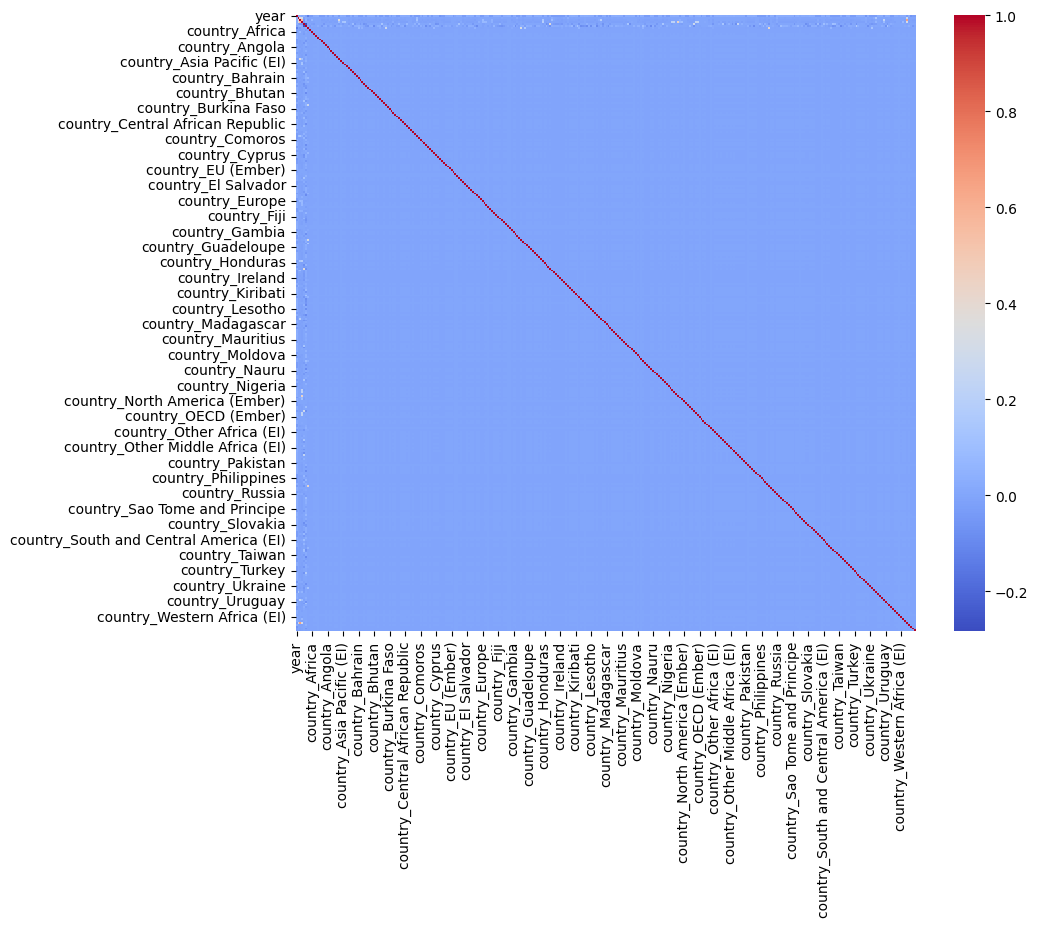

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(energy_df.corr(), cmap="coolwarm")
plt.show()

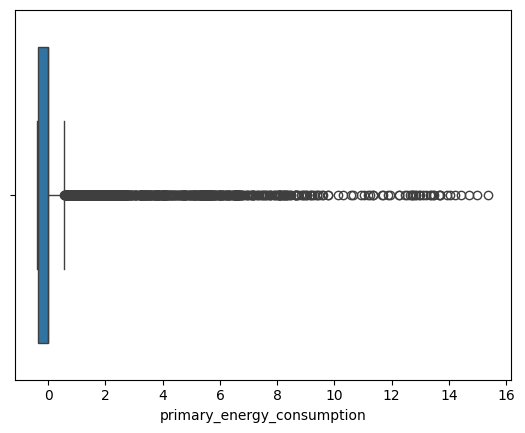

In [29]:
sns.boxplot(x=energy_df["primary_energy_consumption"])
plt.show()

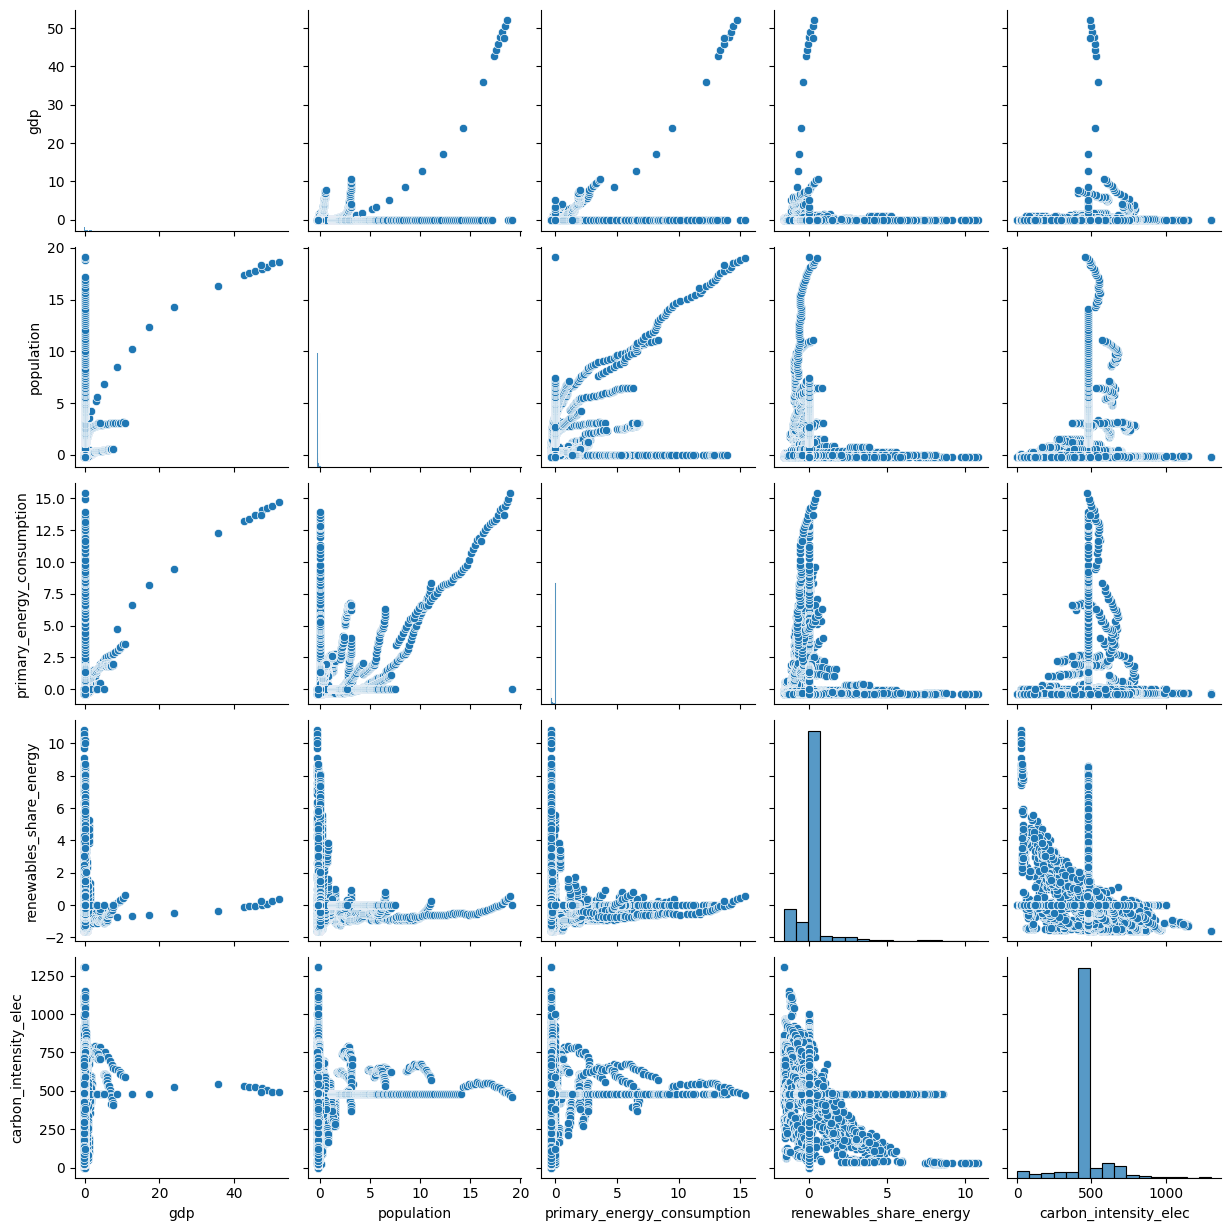

In [30]:
sns.pairplot(
    energy_df[
        [
            "gdp",
            "population",
            "primary_energy_consumption",
            "renewables_share_energy",
            "carbon_intensity_elec"
        ]
    ]
)

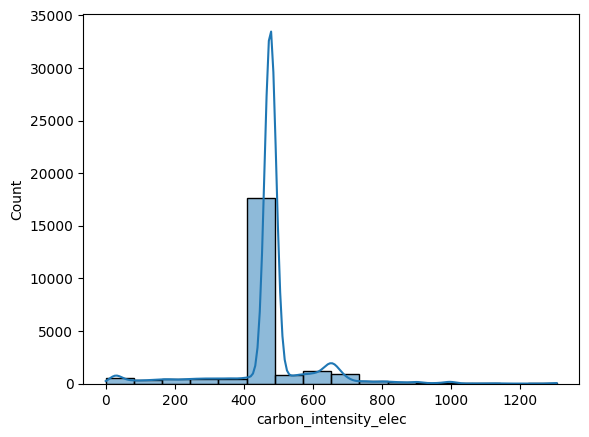

In [28]:
sns.histplot(energy_df["carbon_intensity_elec"], kde=True)
plt.show()

In [31]:
X = energy_df.drop("carbon_intensity_elec", axis=1)

y = energy_df["carbon_intensity_elec"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [34]:
prediction = model.predict(X_test)
prediction

array([483.16319327, 630.92495365, 494.12546056, ..., 564.32854807,
       476.08036768, 448.42210743])

In [35]:
mae = mean_absolute_error(y_test, prediction)

mse = mean_squared_error(y_test, prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, prediction)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 59.76901236906426
MSE : 8527.914266950746
RMSE : 92.34670685493201
R2 Score : 0.469785924416496


In [36]:
# Why fill missing values?
# To avoid losing useful data and ensure the model can be trained.

# Why feature engineering?
# Energy per person helps compare countries of different population sizes.

# Why encoding?
# Machine learning models require numerical inputs.

# Why scaling?
# Standardizes numerical features for stable model training.

# Why train-test split?
# To evaluate model performance on unseen data.

# Error Interpretation:
# MAE -> Average prediction error.
# MSE -> Penalizes larger errors more heavily.
# RMSE -> Error in the original CO₂ units.
# R² Score -> Measures how well the model explains the variance (closer to 1 is better).